# Reconocimiento de hojas de plantas

Proyecto de **Visión por Computador** usando el dataset [Flavia](https://flavia.sourceforge.net/).

**Pipeline:** Adquisición → Preprocesamiento → Extracción de características → Clasificación

**Clases (6):**
1. Acer Palmatum
2. Cedrus Deodara
3. Citrus Reticulata Blanco
4. Ginkgo Biloba
5. Liriodendron Chinense
6. Nerium Oleander

**Clasificadores:** SVM, KNN y Perceptrón Multicapa (MLP)

Toda la lógica del proceso se implementa en este cuaderno.

In [1]:
import sys
# Verificar intérprete activo del kernel antes de instalar dependencias
print('Intérprete de este kernel:', sys.executable)
%pip install -q numpy matplotlib opencv-python scikit-learn pandas


Intérprete de este kernel: C:\Users\kevin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\kevin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Importamos las librerías necesarias.

In [2]:
import math
from dataclasses import dataclass
from pathlib import Path

import cv2                    # lectura, preprocesamiento y descriptores geométricos
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Tamaño por defecto de las figuras matplotlib
plt.rcParams['figure.figsize'] = (12, 5)


## Configuración

Rutas del dataset Flavia (`Leaves/`) y rangos de archivos por clase.

In [3]:
# Rutas del proyecto, relativas a la carpeta del notebook
NOTEBOOK_DIR = Path.cwd()
LEAVES_DIR = NOTEBOOK_DIR / 'Leaves'          # imágenes originales Flavia
DATOS_DIR = NOTEBOOK_DIR / 'datos'
PROCESADAS_DIR = DATOS_DIR / 'procesadas'     # imágenes binarizadas y recortadas
FEATURES_CSV = DATOS_DIR / 'caracteristicas.csv'

# Rangos de archivos en Flavia: cada clase tiene imágenes NNNN.jpg en un intervalo
# Fuente: https://flavia.sourceforge.net/
CLASES = {
    'Acer Palmatum': (1268, 1323),
    'Cedrus Deodara': (2347, 2423),
    'Citrus Reticulata Blanco': (3566, 3621),
    'Ginkgo Biloba': (2424, 2485),
    'Liriodendron Chinense': (3511, 3563),
    'Nerium Oleander': (2547, 2612),
}

IMAGENES_POR_CLASE = 50   # según la consigna del taller
TAMANO_IMAGEN = (300, 300)

# Nombres de las 17 características del vector descriptor
NOMBRES_CARACTERISTICAS = [
    'area', 'perimetro', 'eje_mayor', 'eje_menor',
    'ancho_bbox', 'alto_bbox', 'relacion_aspecto', 'factor_forma',
    'rectangularidad', 'relacion_perimetro_diametro',
    'hu_1', 'hu_2', 'hu_3', 'hu_4', 'hu_5', 'hu_6', 'hu_7',
]


def rutas_clase(clase, leaves_dir=LEAVES_DIR, limite=IMAGENES_POR_CLASE):
    # Devuelve las rutas de imagen de una clase según los rangos del dataset Flavia
    inicio, fin = CLASES[clase]
    rutas = []
    for numero in range(inicio, fin + 1):
        if len(rutas) >= limite:
            break
        ruta = leaves_dir / f'{numero:04d}.jpg'
        if ruta.exists():
            rutas.append(ruta)
    return rutas


## 1. Adquisición de imagen

Las imágenes provienen del dataset **Flavia**, ubicado en `Leaves/` (archivos `NNNN.jpg` sobre fondo blanco).

Se seleccionan **50 imágenes por clase** según los rangos definidos en [flavia.sourceforge.net](https://flavia.sourceforge.net/).

In [4]:
# Comprobar que el dataset Flavia está disponible
if not LEAVES_DIR.exists():
    raise FileNotFoundError(f'No se encontró el dataset en {LEAVES_DIR}')

print(f'Dataset: {LEAVES_DIR}')
print(f'Imágenes por clase: {IMAGENES_POR_CLASE}\n')

# Resumen de imágenes encontradas por especie
for clase, (inicio, fin) in CLASES.items():
    rutas = rutas_clase(clase)
    print(f'  {clase}: {len(rutas)} imágenes (rango {inicio:04d}–{fin:04d})')


Dataset: c:\Users\kevin\Downloads\FrutosRojos\hojas\Leaves
Imágenes por clase: 50

  Acer Palmatum: 50 imágenes (rango 1268–1323)
  Cedrus Deodara: 50 imágenes (rango 2347–2423)
  Citrus Reticulata Blanco: 50 imágenes (rango 3566–3621)
  Ginkgo Biloba: 50 imágenes (rango 2424–2485)
  Liriodendron Chinense: 50 imágenes (rango 3511–3563)
  Nerium Oleander: 50 imágenes (rango 2547–2612)


## 2. Preprocesamiento

1. Redimensionar a **300×300** píxeles
2. Convertir a **escala de grises** (0–255)
3. Rotar si es necesario
4. Aplicar **filtro de suavizado** (Gaussian blur)
5. **Umbralizar** (binarización: hoja = píxeles negros)
6. **Recortar** al bounding box de la hoja
7. Imagen procesada lista para extraer características

In [ ]:
def preprocesar_imagen(imagen, tamano=TAMANO_IMAGEN, angulo_rotacion=0.0,
                        umbral=None, kernel_blur=(5, 5)):
    # Pipeline de preprocesamiento:
    # resize -> grises -> rotación -> blur -> umbral -> recorte al bbox de la hoja
    if imagen is None or imagen.size == 0:
        raise ValueError('La imagen de entrada es inválida.')

    # 1. Redimensionar a 300x300
    img = cv2.resize(imagen, tamano, interpolation=cv2.INTER_AREA)

    # 2. Convertir a escala de grises (0-255)
    if len(img.shape) == 3:
        gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gris = img.copy()

    # 3. Rotación opcional (0 = sin rotar)
    if angulo_rotacion != 0.0:
        centro = (gris.shape[1] // 2, gris.shape[0] // 2)
        matriz = cv2.getRotationMatrix2D(centro, angulo_rotacion, 1.0)
        gris = cv2.warpAffine(gris, matriz, (gris.shape[1], gris.shape[0]),
                              flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT,
                              borderValue=255)

    # 4. Suavizado para facilitar la segmentación de la hoja
    suavizada = cv2.GaussianBlur(gris, kernel_blur, 0)

    # 5. Binarización: hoja = píxeles negros, fondo = blancos
    if umbral is None:
        _, binaria = cv2.threshold(suavizada, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    else:
        _, binaria = cv2.threshold(suavizada, umbral, 255, cv2.THRESH_BINARY)

    # 6. Recortar al bounding box de los píxeles negros (la hoja)
    mascara_hoja = (binaria == 0).astype(np.uint8) * 255
    puntos = cv2.findNonZero(mascara_hoja)
    if puntos is None:
        return binaria

    x, y, w, h = cv2.boundingRect(puntos)
    return binaria[y:y + h, x:x + w]


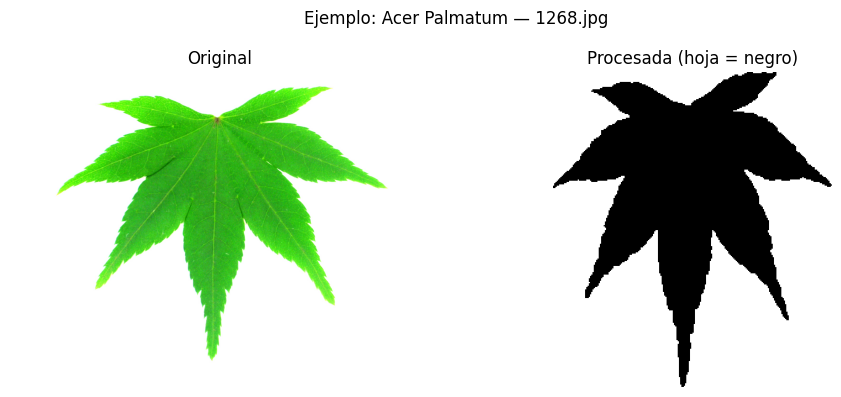

In [6]:
# Ejemplo visual del preprocesamiento con la primera hoja de Acer Palmatum
clase_ejemplo = list(CLASES.keys())[0]
ruta_ejemplo = rutas_clase(clase_ejemplo)[0]

img_original = cv2.imread(str(ruta_ejemplo))
img_procesada = preprocesar_imagen(img_original)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(img_procesada, cmap='gray')
axes[1].set_title('Procesada (hoja = negro)')
axes[1].axis('off')
plt.suptitle(f'Ejemplo: {clase_ejemplo} — {ruta_ejemplo.name}')
plt.tight_layout()
plt.show()


## 3. Extracción de características

Descriptores geométricos calculados con OpenCV:

| # | Característica | Método |
|---|----------------|--------|
| 1 | Eje mayor / menor | PCA (`cv2.PCACompute2`) |
| 2 | Bounding box | `cv2.boundingRect` / `cv2.findContours` |
| 3 | Área (A) | `cv2.contourArea` |
| 4 | Perímetro (P) | `cv2.arcLength` |
| 5 | Relación de aspecto | ancho / alto |
| 6 | Factor de forma | 4πA / P² |
| 7 | Rectangularidad | (ancho × alto) / A |
| 8 | Relación P/diámetro | P / ancho |
| 9 | Momentos Hu (×7) | `cv2.HuMoments` (imagen invertida) |

In [7]:
# ---------------------------------------------------------------------------
# Funciones de extracción de características geométricas
# Entrada: imagen binaria procesada (hoja negra sobre fondo blanco)
# Salida: diccionario con 17 descriptores numéricos por hoja
# ---------------------------------------------------------------------------

def _contorno_principal(imagen_binaria):
    # Localiza el borde de la hoja con cv2.findContours.
    # Si hay varios contornos (ruido), se toma el de mayor área.
    # Crear máscara: 255 donde hay hoja, 0 en el fondo
    mascara = (imagen_binaria == 0).astype(np.uint8) * 255
    # RETR_EXTERNAL: solo contornos externos (no agujeros internos)
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contornos:
        raise ValueError('No se encontró contorno de la hoja.')
    return max(contornos, key=cv2.contourArea)


def _ejes_pca(contorno):
    # Calcula eje mayor y menor con PCA sobre los puntos del contorno.
    # Los autovectores indican la dirección de máxima y mínima dispersión.
    puntos = contorno.reshape(-1, 2).astype(np.float32)
    if len(puntos) < 2:
        return 0.0, 0.0
    # PCACompute2 devuelve: media, autovectores y autovalores
    _, _, eigenvalores = cv2.PCACompute2(puntos, mean=np.array([]))
    # Semieje = sqrt(autovalor); eje completo = 2 * semieje
    eje_mayor = 2.0 * math.sqrt(float(eigenvalores[0, 0]))
    eje_menor = 2.0 * math.sqrt(float(eigenvalores[1, 0]))
    return eje_mayor, eje_menor


def _momentos_hu(imagen_binaria):
    # Momentos Hu: 7 descriptores invariantes a traslación, escala y rotación.
    # Se invierten píxeles (hoja blanca) y se aplica log10 para estabilizar valores.
    invertida = cv2.bitwise_not(imagen_binaria)
    momentos = cv2.moments(invertida)
    hu = cv2.HuMoments(momentos).flatten()
    # Transformación logarítmica estándar (signo preservado)
    return [-math.copysign(1.0, v) * math.log10(abs(v) + 1e-12) for v in hu]


def extraer_caracteristicas(imagen_procesada):
    # Construye el vector de 17 características geométricas para una hoja.
    contorno = _contorno_principal(imagen_procesada)

    # --- Medidas directas (OpenCV) ---
    area = float(cv2.contourArea(contorno))           # A: píxeles dentro del contorno
    perimetro = float(cv2.arcLength(contorno, True))  # P: longitud del borde (cerrado=True)
    eje_mayor, eje_menor = _ejes_pca(contorno)        # ejes de la elipse equivalente
    _, _, ancho, alto = cv2.boundingRect(contorno)    # rectángulo alineado a ejes X/Y

    # --- Ratios geométricos (fórmulas del documento) ---
    # Relación de aspecto: qué tan ancha es respecto a su alto
    relacion_aspecto = float(ancho) / float(alto) if alto > 0 else 0.0
    # Factor de forma: 1.0 = círculo perfecto; valores menores = formas más irregulares
    factor_forma = (4.0 * math.pi * area) / (perimetro ** 2) if perimetro > 0 else 0.0
    # Rectangularidad: qué tan bien llena la hoja su bounding box
    rectangularidad = (float(ancho) * float(alto)) / area if area > 0 else 0.0
    # Relación perímetro/diámetro: P dividido por el ancho del bbox
    relacion_perimetro_diametro = perimetro / float(ancho) if ancho > 0 else 0.0
    hu = _momentos_hu(imagen_procesada)              # 7 momentos Hu (hu_1 ... hu_7)

    # Empaquetar las 17 características en un diccionario ordenado
    valores = [
        area, perimetro, eje_mayor, eje_menor,
        float(ancho), float(alto), relacion_aspecto, factor_forma,
        rectangularidad, relacion_perimetro_diametro, *hu,
    ]
    return dict(zip(NOMBRES_CARACTERISTICAS, valores))


def visualizar_descriptores(imagen_procesada):
    # Genera imagen anotada: contorno (rojo), bbox (verde), ejes PCA (azul/amarillo)
    contorno = _contorno_principal(imagen_procesada)
    visual = cv2.cvtColor(imagen_procesada, cv2.COLOR_GRAY2BGR)

    # Dibujar contorno y bounding box
    cv2.drawContours(visual, [contorno], -1, (0, 0, 255), 1)
    x, y, ancho, alto = cv2.boundingRect(contorno)
    cv2.rectangle(visual, (x, y), (x + ancho, y + alto), (0, 255, 0), 1)

    # Dibujar ejes PCA desde el centroide del contorno
    puntos = contorno.reshape(-1, 2).astype(np.float32)
    if len(puntos) >= 2:
        media, eigenvectores, eigenvalores = cv2.PCACompute2(puntos, mean=np.array([]))
        cx, cy = int(media[0, 0]), int(media[0, 1])
        for i, color in enumerate([(255, 0, 0), (0, 255, 255)]):
            magnitud = math.sqrt(float(eigenvalores[i, 0]))
            dx = int(eigenvectores[i, 0] * magnitud)
            dy = int(eigenvectores[i, 1] * magnitud)
            cv2.line(visual, (cx - dx, cy - dy), (cx + dx, cy + dy), color, 1)
    return visual


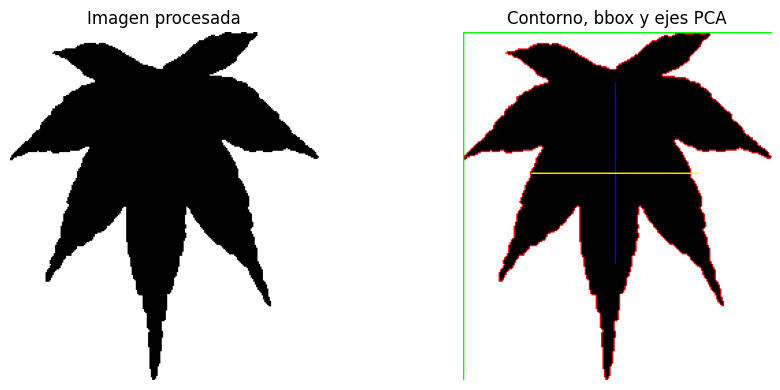

area                           21651.5000
perimetro                       1341.1240
eje_mayor                        133.1160
eje_menor                        123.6292
ancho_bbox                       226.0000
alto_bbox                        255.0000
relacion_aspecto                   0.8863
factor_forma                       0.1513
rectangularidad                    2.6617
relacion_perimetro_diametro        5.9342
hu_1                               3.1043
hu_2                               7.9559
hu_3                              10.3805
hu_4                              10.9458
hu_5                              12.0000
hu_6                              11.9996
hu_7                              12.0000
dtype: float64

In [8]:
# --- Probar extracción con la hoja de ejemplo del punto 2 ---

# Calcular los 17 descriptores numéricos
descriptores = extraer_caracteristicas(img_procesada)
# Generar imagen anotada con contorno, bbox y ejes
visual = visualizar_descriptores(img_procesada)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_procesada, cmap='gray')
axes[0].set_title('Imagen procesada')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(visual, cv2.COLOR_BGR2RGB))
axes[1].set_title('Contorno, bbox y ejes PCA')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Mostrar el vector de características como tabla (una fila = una hoja)
pd.Series(descriptores).round(4)


### Construir dataset completo

Procesamos las 50 imágenes de cada clase y guardamos el vector de características para luego clasificarlas

In [9]:
def construir_dataset(leaves_dir=LEAVES_DIR, procesadas_dir=PROCESADAS_DIR,
                      limite=IMAGENES_POR_CLASE, guardar_procesadas=True):
    # Recorre las 6 clases: preprocesa cada imagen, extrae características
    # y devuelve un DataFrame listo para entrenar clasificadores.
    filas = []
    procesadas_dir.mkdir(parents=True, exist_ok=True)

    for clase in CLASES:
        # Obtener hasta 50 imágenes de esta especie según rangos Flavia
        imagenes = rutas_clase(clase, leaves_dir, limite)
        if not imagenes:
            print(f'  [aviso] sin imágenes para {clase}')
            continue

        if guardar_procesadas:
            destino_clase = procesadas_dir / clase.replace(' ', '_')
            destino_clase.mkdir(parents=True, exist_ok=True)

        for ruta in imagenes:
            imagen = cv2.imread(str(ruta))
            if imagen is None:
                print(f'  [omitida] no se pudo leer: {ruta.name}')
                continue

            # Aplicar pipeline de preprocesamiento (punto 2)
            procesada = preprocesar_imagen(imagen)
            if procesada.size == 0:
                print(f'  [omitida] preprocesamiento vacío: {ruta.name}')
                continue

            if guardar_procesadas:
                cv2.imwrite(str(destino_clase / ruta.name), procesada)

            # Extraer vector de características y asociarlo a su etiqueta (clase)
            caracteristicas = extraer_caracteristicas(procesada)
            filas.append({'archivo': ruta.name, 'clase': clase, **caracteristicas})

    return pd.DataFrame(filas)


In [11]:
# Construir el dataset completo: 50 imágenes × 6 clases = 300 muestras

print('Extrayendo características de todo el dataset...')
df = construir_dataset(guardar_procesadas=True)

# Persistir características en CSV para no recalcular en futuras ejecuciones
DATOS_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(FEATURES_CSV, index=False)
print(f'Total: {len(df)} muestras — guardado en {FEATURES_CSV}')

# Vista previa: columnas 'archivo' y 'clase' + 17 descriptores numéricos
df.head()


Extrayendo características de todo el dataset...
Total: 300 muestras — guardado en c:\Users\kevin\Downloads\FrutosRojos\hojas\datos\caracteristicas.csv


,archivo,clase,area,perimetro,eje_mayor,eje_menor,ancho_bbox,alto_bbox,relacion_aspecto,factor_forma,rectangularidad,relacion_perimetro_diametro,hu_1,hu_2,hu_3,hu_4,hu_5,hu_6,hu_7
0,1268.jpg,Acer Palmatum,21651.5,1341.124014,133.116021,123.629183,226.0,255.0,0.886275,0.151272,2.661709,5.934177,3.104300,7.955949,10.380474,10.945811,12.0,11.999553,12.0
1,1269.jpg,Acer Palmatum,22994.0,1455.047892,138.679634,126.440810,232.0,270.0,0.859259,0.136480,2.724189,6.271758,3.094388,7.671159,10.423515,10.779964,12.0,11.999035,-12.0
2,1270.jpg,Acer Palmatum,26418.0,1397.248903,146.828776,120.847625,230.0,262.0,0.877863,0.170044,2.281021,6.074995,3.117628,8.153623,10.538283,11.602704,12.0,11.999962,12.0
3,1271.jpg,Acer Palmatum,19786.0,1332.964631,132.140994,119.890893,212.0,255.0,0.831373,0.139936,2.732235,6.287569,3.094321,7.826071,10.517537,10.869182,12.0,11.999392,12.0
4,1272.jpg,Acer Palmatum,22567.5,1435.633679,138.740245,127.033460,230.0,261.0,0.881226,0.137596,2.660020,6.241886,3.097926,7.949051,10.925714,11.070945,12.0,11.999723,-12.0


## 4. Clasificación

Entrenamos tres clasificadores con el vector de características de cada imagen:
- **SVM** (Máquina de Vectores de Soporte)
- **KNN** (K-Vecinos más Cercanos, k=5)
- **MLP** (Perceptrón Multicapa)

Se usa división estratificada 75% entrenamiento / 25% prueba.

In [12]:
# ---------------------------------------------------------------------------
# Clasificación: SVM, KNN y MLP
# Entrada: DataFrame con columnas de características + etiqueta 'clase'
# ---------------------------------------------------------------------------

@dataclass
class ResultadoClasificador:
    # Guarda nombre, precisión, reporte, matriz de confusión y modelo entrenado
    nombre: str
    precision: float
    reporte: str
    matriz_confusion: np.ndarray
    modelo: Pipeline


def entrenar_clasificadores(df, columnas_features, columna_etiqueta='clase',
                            test_size=0.25, random_state=42):
    # Entrena SVM, KNN y MLP sobre el mismo split de datos.
    # Las características se escalan con StandardScaler porque SVM, KNN y MLP
    # son sensibles a diferencias de magnitud entre features.

    # X = matriz de características, y = etiquetas de clase (nombre de la planta)
    x = df[columnas_features].values
    y = df[columna_etiqueta].values

    # Partición estratificada: 75% train / 25% test, misma proporción de clases
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Definición de los tres clasificadores pedidos en la consigna
    modelos = {
        # SVM con kernel RBF: separa clases en un espacio de mayor dimensión
        'SVM': SVC(kernel='rbf', C=10.0, gamma='scale', random_state=random_state),
        # KNN: clasifica según las 5 hojas más similares en el espacio de features
        'KNN': KNeighborsClassifier(n_neighbors=5),
        # MLP: red neuronal con dos capas ocultas (64 y 32 neuronas)
        'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000,
                           random_state=random_state, early_stopping=False),
    }

    resultados = []
    for nombre, clasificador in modelos.items():
        # Pipeline: primero escalar, luego entrenar el clasificador
        pipeline = Pipeline([('scaler', StandardScaler()), ('clf', clasificador)])
        pipeline.fit(x_train, y_train)

        # Evaluar solo con datos de prueba (no vistos durante el entrenamiento)
        predicciones = pipeline.predict(x_test)
        precision = accuracy_score(y_test, predicciones)

        resultados.append(ResultadoClasificador(
            nombre=nombre,
            precision=precision,
            reporte=classification_report(y_test, predicciones),
            matriz_confusion=confusion_matrix(y_test, predicciones),
            modelo=pipeline,
        ))
    return resultados


In [12]:
# Entrenar SVM, KNN y MLP con las 17 características de cada hoja
resultados = entrenar_clasificadores(df, NOMBRES_CARACTERISTICAS)

# Tabla resumen: un renglón por clasificador con su precisión global
resumen = pd.DataFrame([
    {'Clasificador': r.nombre, 'Precisión': f'{r.precision:.2%}'}
    for r in resultados
])
resumen


,Clasificador,Precisión
0,SVM,98.67%
1,KNN,97.33%
2,MLP,97.33%


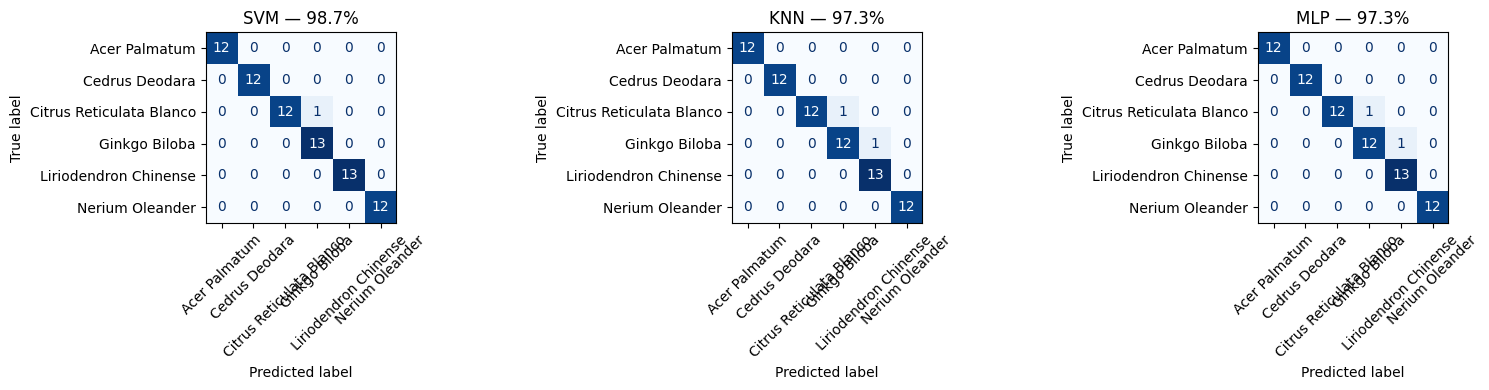

In [13]:
# Matrices de confusión: comparar predicciones vs. etiquetas reales
# Cada fila = clase verdadera; cada columna = clase predicha
# La diagonal principal indica aciertos

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
clases_orden = sorted(df['clase'].unique())

for ax, resultado in zip(axes, resultados):
    disp = ConfusionMatrixDisplay(resultado.matriz_confusion, display_labels=clases_orden)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(f'{resultado.nombre} — {resultado.precision:.1%}')

plt.tight_layout()
plt.show()


In [14]:
# Reporte detallado por clase para cada clasificador
# precision = de las predichas como X, cuántas eran realmente X
# recall    = de las que eran X, cuántas se detectaron correctamente
# f1-score  = media armónica entre precision y recall

for resultado in resultados:
    print(f'\n{"=" * 50}')
    print(f' {resultado.nombre} — Precisión: {resultado.precision:.2%}')
    print('=' * 50)
    print(resultado.reporte)



 SVM — Precisión: 98.67%
                          precision    recall  f1-score   support

           Acer Palmatum       1.00      1.00      1.00        12
          Cedrus Deodara       1.00      1.00      1.00        12
Citrus Reticulata Blanco       1.00      0.92      0.96        13
           Ginkgo Biloba       0.93      1.00      0.96        13
   Liriodendron Chinense       1.00      1.00      1.00        13
         Nerium Oleander       1.00      1.00      1.00        12

                accuracy                           0.99        75
               macro avg       0.99      0.99      0.99        75
            weighted avg       0.99      0.99      0.99        75


 KNN — Precisión: 97.33%
                          precision    recall  f1-score   support

           Acer Palmatum       1.00      1.00      1.00        12
          Cedrus Deodara       1.00      1.00      1.00        12
Citrus Reticulata Blanco       1.00      0.92      0.96        13
           Ginkgo Bi

## 5. Predicción sobre una imagen nueva

Clasificación de una hoja **distinta** a la usada en el punto 2 (otra clase e imagen), usando el mejor modelo entrenado.

Mejor clasificador: SVM (98.67%)
Imagen: 3536.jpg
Clase real: Liriodendron Chinense
Predicción: Liriodendron Chinense


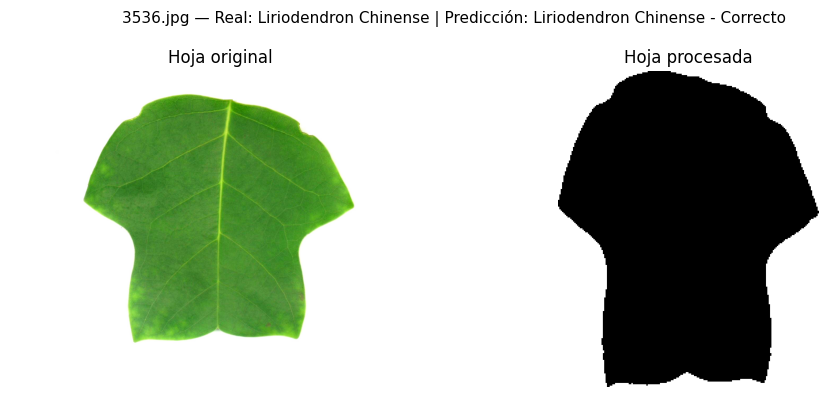

In [15]:
# --- Clasificar una hoja nueva (distinta a la del punto 2) ---

# Seleccionar el clasificador con mejor precisión en el conjunto de prueba
mejor = max(resultados, key=lambda r: r.precision)
print(f'Mejor clasificador: {mejor.nombre} ({mejor.precision:.2%})')

# Elegir otra especie e imagen (Liriodendron Chinense, imagen #26 del rango)
clase_prueba = 'Liriodendron Chinense'
ruta_prueba = rutas_clase(clase_prueba)[25]

# Paso 1: cargar y preprocesar la hoja de prueba
img_test = cv2.imread(str(ruta_prueba))
proc_test = preprocesar_imagen(img_test)

# Paso 2: convertir descriptores a vector 1×17 (formato que espera sklearn)
vector = np.array(list(extraer_caracteristicas(proc_test).values())).reshape(1, -1)

# Paso 3: predecir con el pipeline entrenado (incluye escalado interno)
prediccion = mejor.modelo.predict(vector)[0]

print(f'Imagen: {ruta_prueba.name}')
print(f'Clase real: {clase_prueba}')
print(f'Predicción: {prediccion}')

# Mostrar la hoja clasificada: original vs. procesada
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB))
axes[0].set_title('Hoja original')
axes[0].axis('off')
axes[1].imshow(proc_test, cmap='gray')
axes[1].set_title('Hoja procesada')
axes[1].axis('off')

acerto = '- Correcto' if prediccion == clase_prueba else '- Incorrecto'
plt.suptitle(
    f'{ruta_prueba.name} — Real: {clase_prueba} | Predicción: {prediccion} {acerto}',
    fontsize=11,
)
plt.tight_layout()
plt.show()
